In [1]:
import pdb
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.cux001 import FactorEvaluate1
from lib.bck002 import rebuild_executed_signal_for_eval

In [3]:
period = 5
ret_col = f"nxt1_ret_{period}h"

signal_path = "/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/signal/rl/1018806311332385/erband_signal/1002_test.feather"

position_path = '/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/backtest/rl/1013836755991964/1018806311332385/erband_signal/1002_test/position_data.feather'

trader_path = '/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/backtest/rl/1013836755991964/1018806311332385/erband_signal/1002_test/trade_records.feather'


In [4]:
signal_data = pd.read_feather(signal_path)
position_data = pd.read_feather(position_path)
trader_data = pd.read_feather(trader_path) 

trader_data['trade_time'] = pd.to_datetime(
    trader_data['date'].astype(str) +
    trader_data['min_time'].astype(str).str.zfill(4),
    format='%Y-%m-%d%H%M')

In [5]:
### 目标仓位数据和原始信号数据是否一致
position_open = position_data[position_data['signal_type'] == 'open'].copy()
position_check = position_open[[
    'trade_time', 'code', 'direction', 'numbers', 'pair_id'
]].merge(signal_data[['trade_time', 'code', 'signal', 'nxt1_ret_5h']],
         on=['trade_time', 'code'],
         how='left')
print("position open vs raw signal diff:")
print((position_check['direction'] != position_check['signal']).mean())
print(pd.crosstab(position_check['direction'], position_check['signal']))


position open vs raw signal diff:
0.0
signal        -1      1
direction              
-1         51784      0
 1             0  83206


In [6]:
### 目标仓位数据和成交数据是否一致
trader_regular = trader_data[trader_data['signal_type'] == 'regular'].copy()
trade_check = trader_regular[[
    'trade_time', 'code', 'direction', 'numbers', 'exec_price', 'pnl',
    'signal_type'
]].merge(position_data[[
    'trade_time', 'code', 'direction', 'numbers', 'signal_type'
]],
         on=['trade_time', 'code', 'direction', 'numbers'],
         how='left',
         suffixes=('_trade', '_position'))
print("trade records missing position rows:")
print(trade_check['signal_type_position'].isna().mean())
print(trade_check[trade_check['signal_type_position'].isna()].head(20))


trade records missing position rows:
0.0
Empty DataFrame
Columns: [trade_time, code, direction, numbers, exec_price, pnl, signal_type_trade, signal_type_position]
Index: []


In [7]:
### 原始信号和成交数据是否一致
open_trade = trade_check[trade_check['signal_type_position'] == 'open'].copy()
open_cmp = open_trade.merge(
    signal_data[["trade_time", "code", "signal", "nxt1_ret_5h"]],
    on=["trade_time", "code"],
    how="left"
)
bad_open = open_cmp[
    open_cmp["direction"] != open_cmp["signal"]
]
print("open diff ratio:")
print(len(bad_open) / len(open_cmp))
print(pd.crosstab(open_cmp["direction"], open_cmp["signal"]))

open diff ratio:
0.0
signal        -1      1
direction              
-1         67997      0
 1             0  97456


In [8]:
evaluate1 = FactorEvaluate1(factor_data=position_check,
                                   factor_name='direction',
                                   ret_name='nxt1_ret_5h',
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="postions",
                                   resampling_win=period,
                                   name="postions")
evaluate1.run()

{'total_ret': 0.6528182823152477,
 'avg_ret': 1.8571095520963168e-05,
 'max_dd': -0.11545237837966282,
 'calmar': 2.432464903988106,
 'sharpe1': 0.014505279781327957,
 'sharpe2': 1.53733670563101,
 'turnover': 0.7741194757480482,
 'win_rate': 0.515596848835977,
 'profit_ratio': 1.0487676481176555,
 'total_ic': 0.016140821987151777,
 'ic_mean': inf,
 'ic_std': nan,
 'ic_ir': nan,
 'factor_autocorr': 0.18567790889254526,
 'ret_autocorr': 0.024651190592366295}

In [9]:
evaluate2 = FactorEvaluate1(factor_data=open_cmp,
                                   factor_name='direction',
                                   ret_name='nxt1_ret_5h',
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="open_cmp",
                                   resampling_win=period,
                                   name="open_cmp")
evaluate2.run()

{'total_ret': 0.9156389501122992,
 'avg_ret': 1.9668628699829917e-05,
 'max_dd': -0.18198988536993244,
 'calmar': 2.0737643686921134,
 'sharpe1': 0.017222850866074082,
 'sharpe2': 1.5771107452871598,
 'turnover': 0.6093379750168212,
 'win_rate': 0.5169528713103004,
 'profit_ratio': 1.0540319573394867,
 'total_ic': 0.018878457326074544,
 'ic_mean': inf,
 'ic_std': nan,
 'ic_ir': nan,
 'factor_autocorr': 0.3724686981231345,
 'ret_autocorr': 0.25949177081626557}

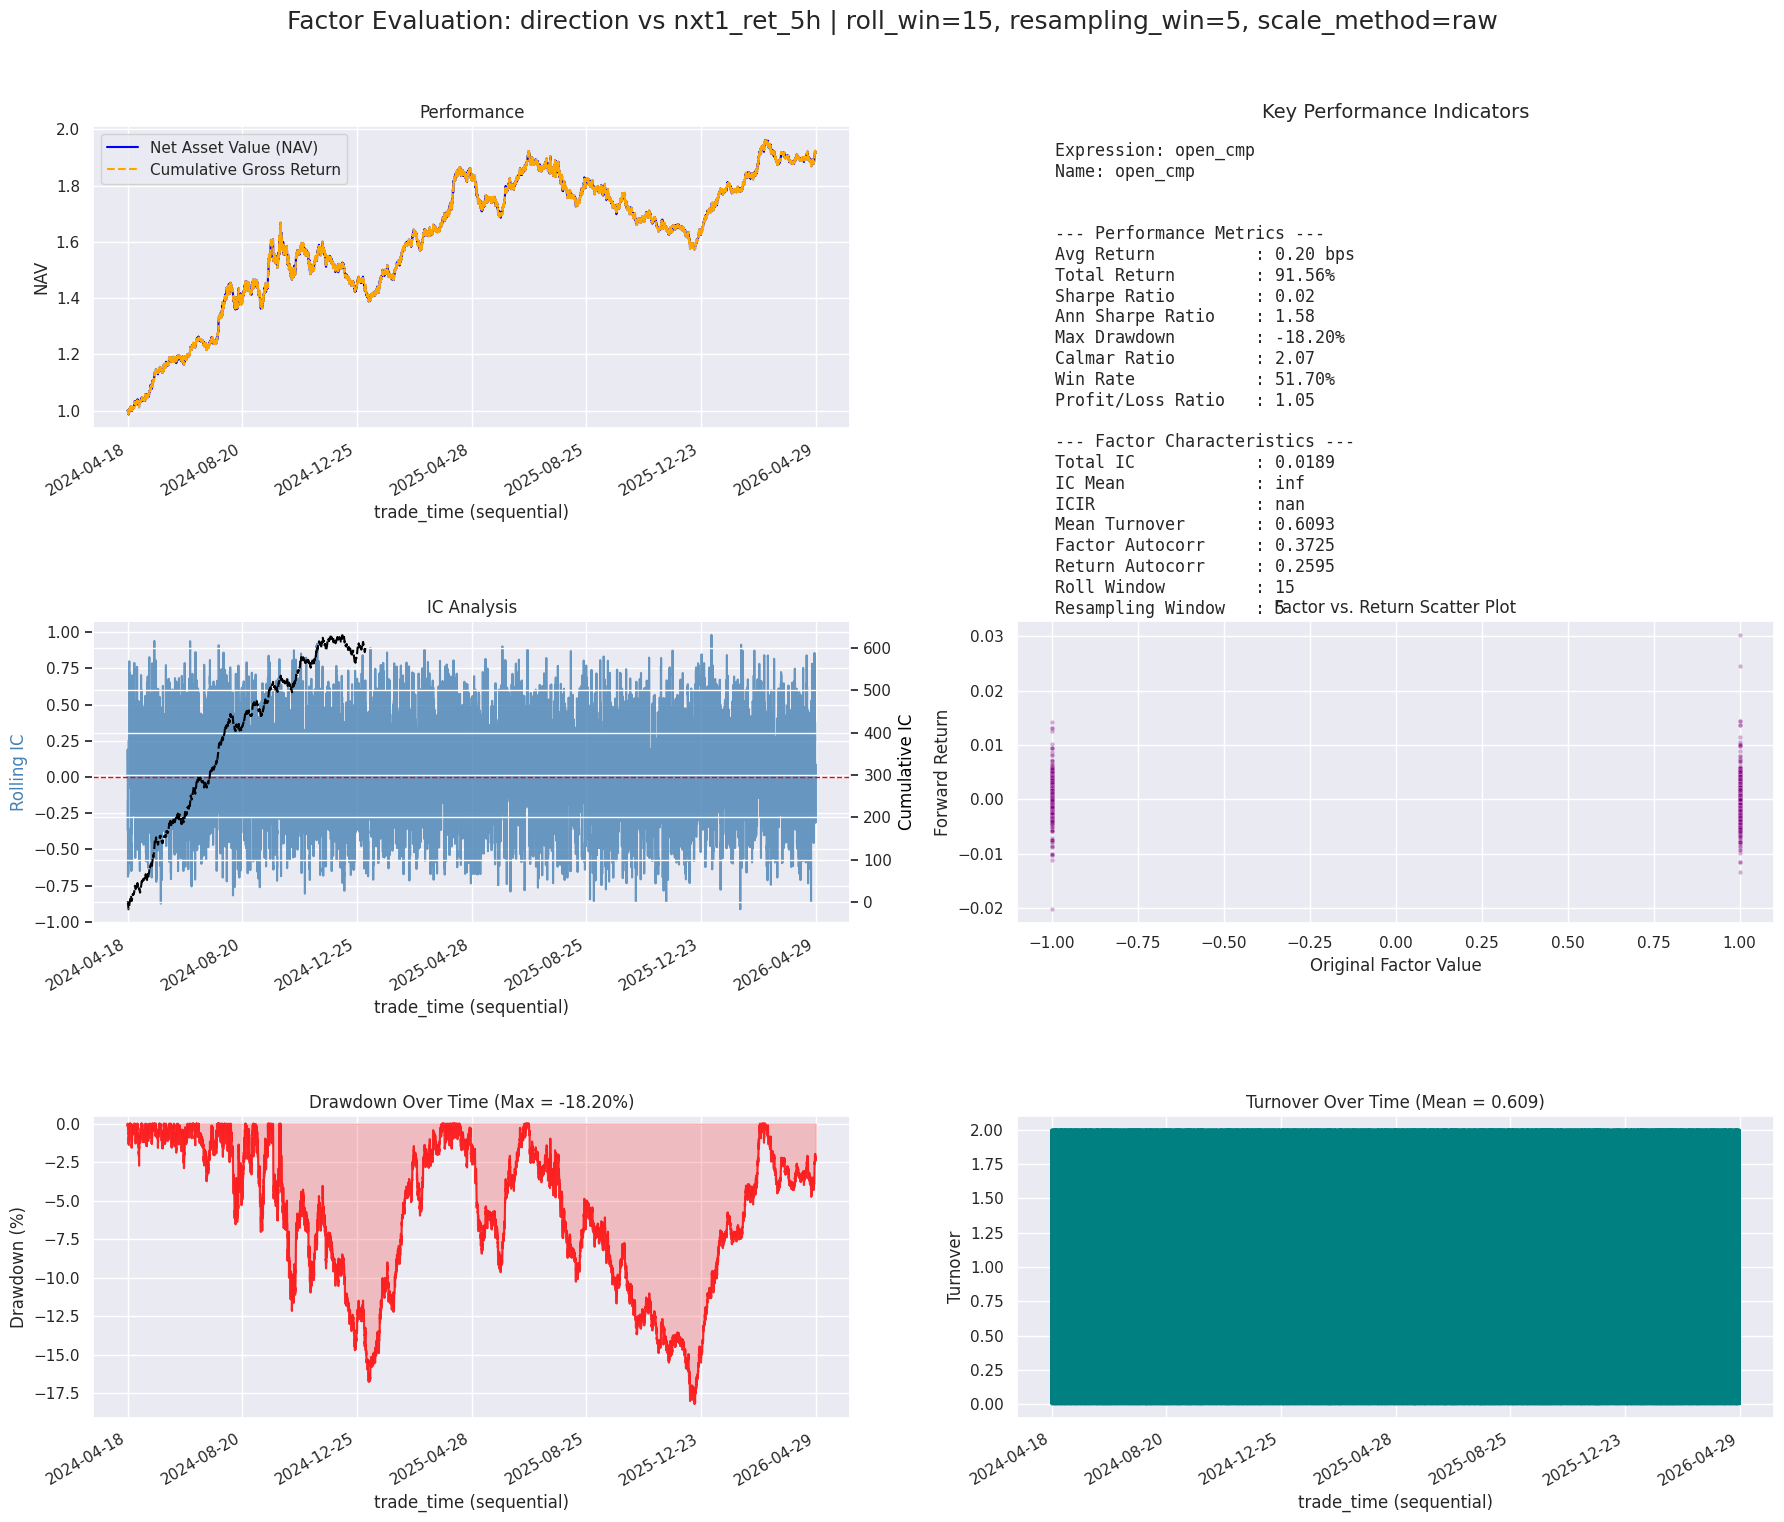

In [10]:
evaluate2.plot_results()

In [14]:
open_cmp[['trade_time','direction', 'nxt1_ret_5h']].tail()

,trade_time,direction,nxt1_ret_5h
165448,2026-04-29 22:51:00,1,-0.000141
165449,2026-04-29 22:54:00,1,-0.000325
165450,2026-04-29 22:54:00,1,-0.000325
165451,2026-04-29 22:55:00,1,0.000093
165452,2026-04-29 22:56:00,1,0.000294


In [15]:
open_cmp.shape

(165453, 10)